In [8]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from welldiag.data.loading import EVENT_NAMES,list_instances, load_instance, sensor_columns, transient_mask

pd.set_option("display.max_columns", 40)
instances = list_instances()
print(f"{len(instances)} instances")
instances.head()

2228 instances


,instance,label,event,source,well,path
0,WELL-00001_20170201010207,0,Normal operation,real,WELL-00001,C:\Users\Arzy\Documents\Welldiag\data\3W\datas...
1,WELL-00001_20170201060114,0,Normal operation,real,WELL-00001,C:\Users\Arzy\Documents\Welldiag\data\3W\datas...
2,WELL-00001_20170201110124,0,Normal operation,real,WELL-00001,C:\Users\Arzy\Documents\Welldiag\data\3W\datas...
3,WELL-00001_20170201160311,0,Normal operation,real,WELL-00001,C:\Users\Arzy\Documents\Welldiag\data\3W\datas...
4,WELL-00001_20170201210228,0,Normal operation,real,WELL-00001,C:\Users\Arzy\Documents\Welldiag\data\3W\datas...


In [4]:
counts = pd.crosstab(instances["event"], instances["source"], margins=True)
counts

source,drawn,real,simulated,All
event,,,,
Abrupt increase of BSW,10,4,114,128
Flow instability,0,343,0,343
Hydrate in production line,0,14,81,95
Hydrate in service line,0,57,150,207
Normal operation,0,594,0,594
Quick restriction in PCK,0,6,215,221
Rapid productivity loss,0,11,439,450
Scaling in PCK,10,36,0,46
Severe slugging,0,32,74,106


In [5]:
real = instances[instances["source"] == "real"]
print(f"{real['well'].nunique()} distinct real wells")
pd.crosstab(real["well"], real["label"])  # which wells have which events: matters for splits

40 distinct real wells


label,0,1,2,3,4,5,6,7,8,9
well,,,,,,,,,,
WELL-00001,93,1,0,1,36,0,0,1,0,0
WELL-00002,209,1,1,0,112,0,3,0,0,0
WELL-00003,26,0,3,0,0,0,0,0,0,0
WELL-00004,12,0,0,0,43,0,3,0,0,0
WELL-00005,81,0,0,0,38,0,0,0,0,0
WELL-00006,113,2,0,0,0,0,0,2,0,0
WELL-00007,2,0,0,0,10,0,0,0,0,0
WELL-00008,57,0,0,0,0,0,0,0,0,0
WELL-00009,0,0,1,0,0,0,0,0,0,0


In [6]:
def summarise(row):
    df = load_instance(row.path, columns=["class"])
    n = len(df)
    return pd.Series({
        "rows": n,
        "duration_h": (df.index[-1] - df.index[0]).total_seconds() / 3600 if n > 1 else 0,
        "transient_frac": transient_mask(df).mean(),
        "median_step_s": df.index.to_series().diff().dt.total_seconds().median(),
    })

summary = instances.join(instances.apply(summarise, axis=1))
summary.groupby("source")[["rows", "duration_h", "median_step_s"]].describe().T

source                       drawn           real     simulated
rows          count      20.000000    1119.000000   1089.000000
              mean   148320.500000   29376.452189  37418.418733
              std    139445.364514   64392.728738  17092.752737
              min     14400.000000    5215.000000  12999.000000
              25%     43200.000000   10775.000000  26999.000000
              50%     86400.000000   21354.000000  29299.000000
              75%    345601.000000   21533.000000  34799.000000
              max    345601.000000  768314.000000  88800.000000
duration_h    count      20.000000    1119.000000   1089.000000
              mean       41.199861       8.159848     10.393727
              std        38.734823      17.886869      4.747987
              min         3.999722       1.448333      3.610556
              25%        11.999722       2.992778      7.499444
              50%        23.999722       5.931389      8.138333
              75%        96.000000       5.981111      9.666111
              max        96.000000     213.420278     24.666389
median_step_s count      20.000000    1119.000000   1089.000000
              mean        1.000000       1.000000      1.000000
              std         0.000000       0.000000      0.000000
              min         1.000000       1.000000      1.000000
              25%         1.000000       1.000000      1.000000
              50%         1.000000       1.000000      1.000000
              75%         1.000000       1.000000      1.000000
              max         1.000000       1.000000      1.000000

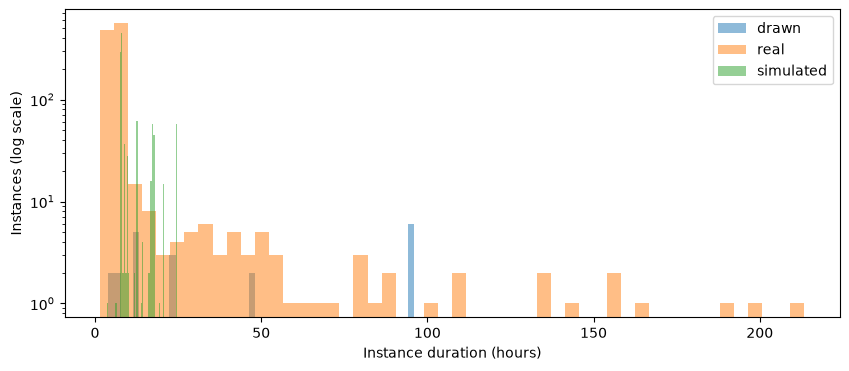

,count,mean,std,min,25%,50%,75%,max
event,,,,,,,,
Abrupt increase of BSW,128.0,0.551927,0.158400,0.158085,0.480008,0.648649,0.648656,0.960139
Flow instability,343.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Hydrate in production line,95.0,0.668540,0.216175,0.340704,0.490759,0.711137,0.896329,0.933331
Hydrate in service line,207.0,0.282027,0.217049,0.000000,0.126927,0.217248,0.506290,0.692955
Quick restriction in PCK,221.0,0.262523,0.030045,0.051864,0.266677,0.266677,0.266677,0.340753
Rapid productivity loss,450.0,0.172604,0.076635,0.095566,0.146763,0.163828,0.163828,0.914068
Scaling in PCK,46.0,0.798690,0.156010,0.372950,0.745248,0.851177,0.916810,0.964340
Severe slugging,106.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Spurious closure of DHSV,38.0,0.221022,0.126537,0.088908,0.125004,0.153999,0.309257,0.584948


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for source, grp in summary.groupby("source"):
    ax.hist(grp["duration_h"], bins=50, alpha=0.5, label=source)
ax.set_xlabel("Instance duration (hours)")
ax.set_ylabel("Instances (log scale)")
ax.set_yscale("log")
ax.legend()
plt.show()

summary[summary["label"] > 0].groupby("event")["transient_frac"].describe()

## Useful sensors to use:

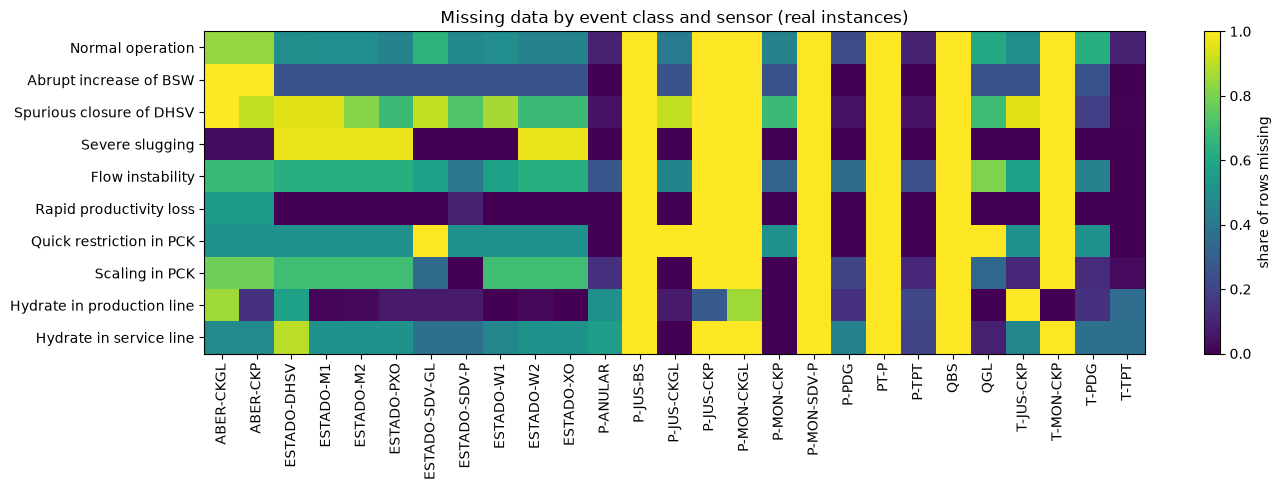

,missing_share,frozen_share
T-TPT,0.075532,0.092940
P-TPT,0.142555,0.176050
P-ANULAR,0.177414,0.183199
P-PDG,0.263494,0.843610
P-MON-CKP,0.354956,0.354781
P-JUS-CKGL,0.384439,0.411975
ESTADO-SDV-P,0.409552,0.990170
T-JUS-CKP,0.497965,0.499553
T-PDG,0.499364,0.793566
ESTADO-W1,0.501459,0.982127


In [12]:
def sensor_health(path):
    df = load_instance(path)
    s = df[sensor_columns(df)]
    return pd.concat({
        "missing": s.isna().mean(),
        "frozen": (s.nunique(dropna=True) <= 1).astype(float),
    })

health = real.set_index("instance")["path"].apply(sensor_health)
missing = health["missing"]
frozen = health["frozen"]

by_class = missing.groupby(real.set_index("instance")["label"]).mean()

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(by_class.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(by_class.shape[1]), by_class.columns, rotation=90)
ax.set_yticks(range(by_class.shape[0]), [EVENT_NAMES[i] for i in by_class.index])
fig.colorbar(im, label="share of rows missing")
ax.set_title("Missing data by event class and sensor (real instances)")
plt.tight_layout()
plt.show()

sensor_table = pd.DataFrame({
    "missing_share": missing.mean(),
    "frozen_share": frozen.mean(),
}).sort_values("missing_share")
sensor_table

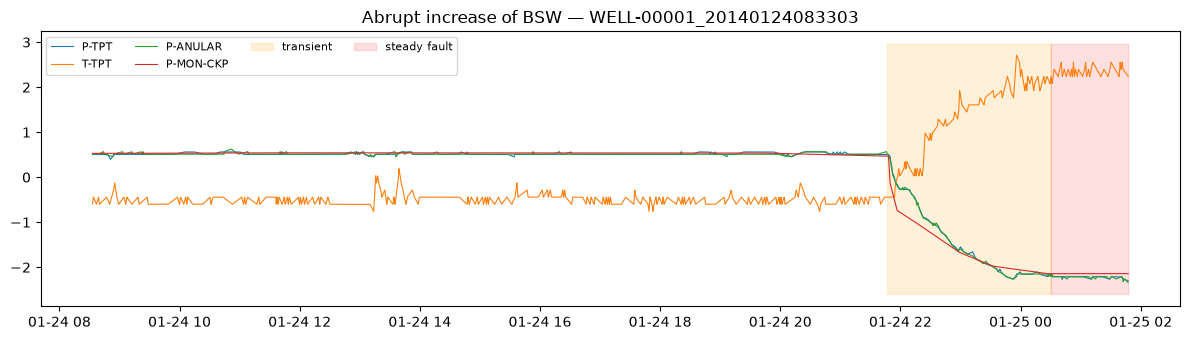

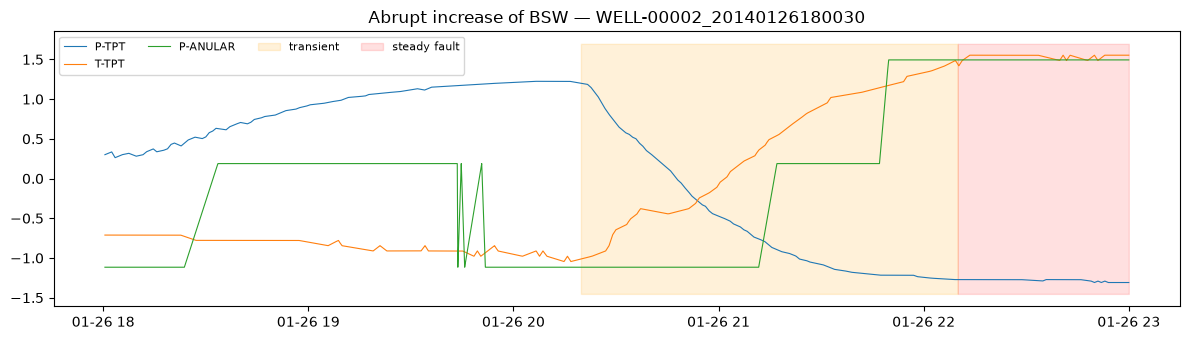

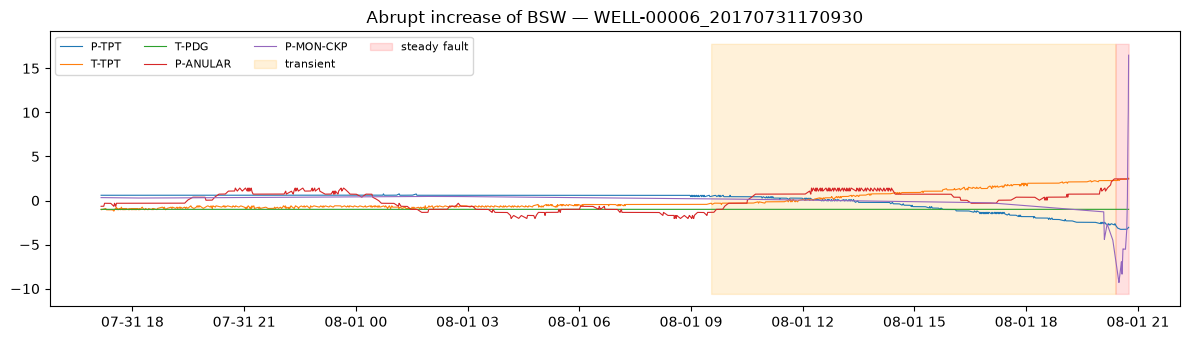

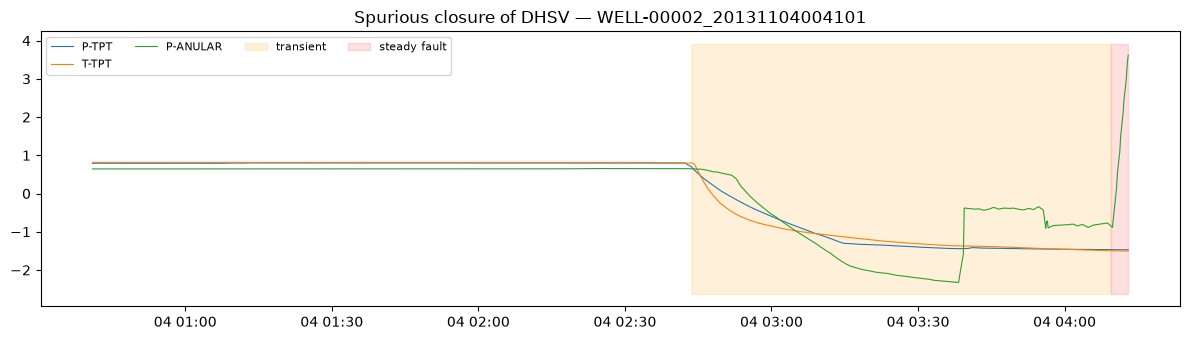

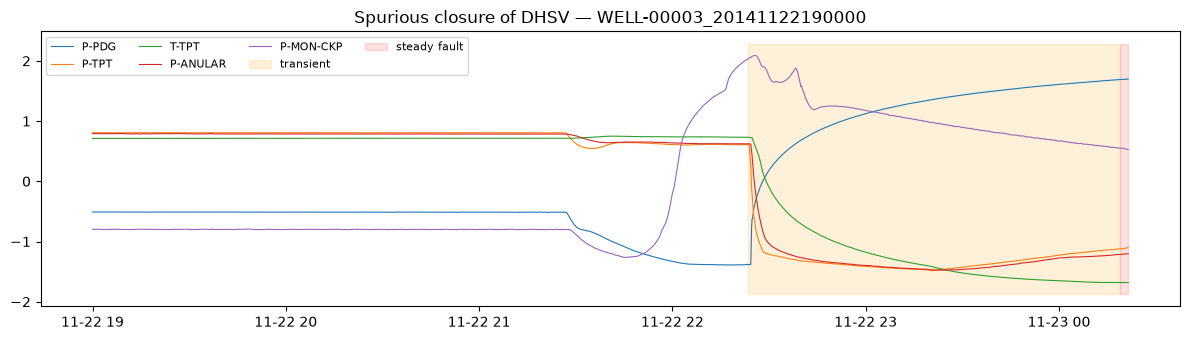

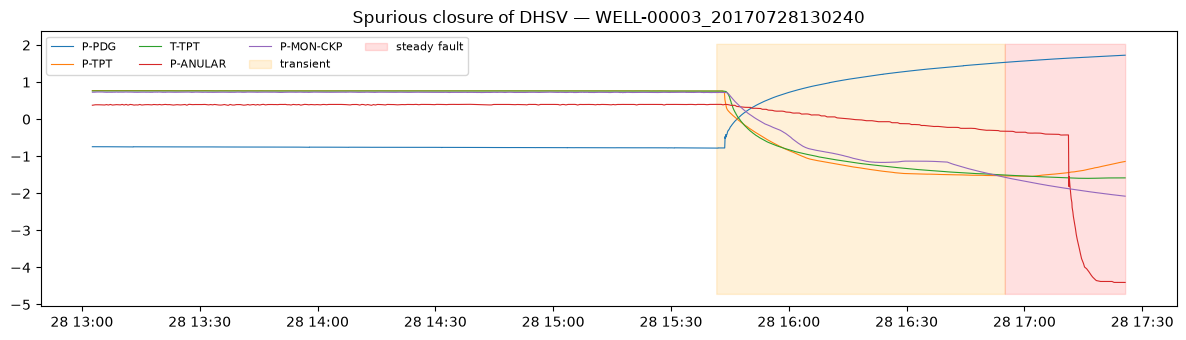

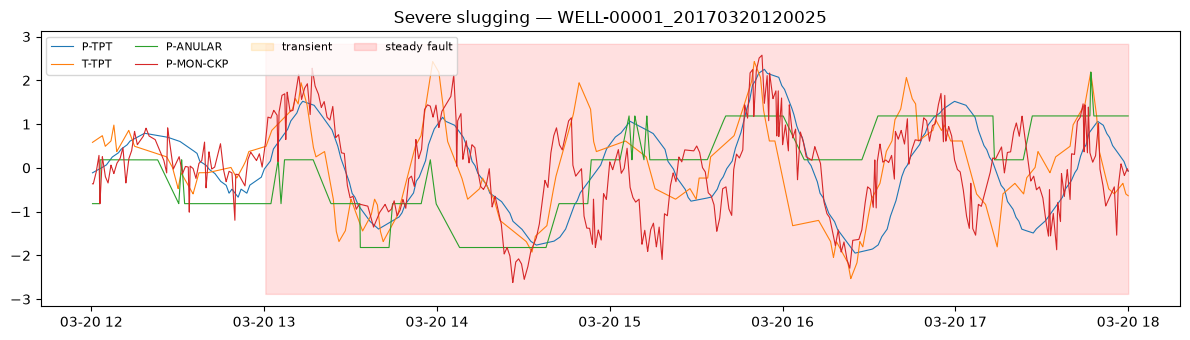

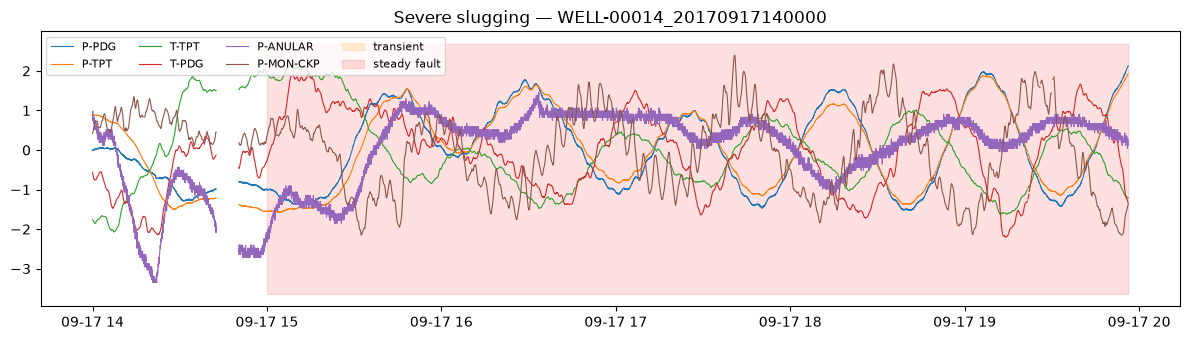

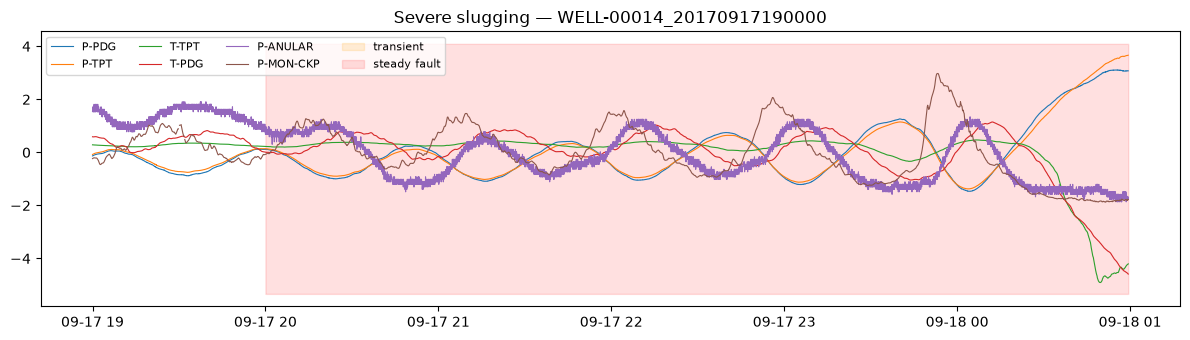

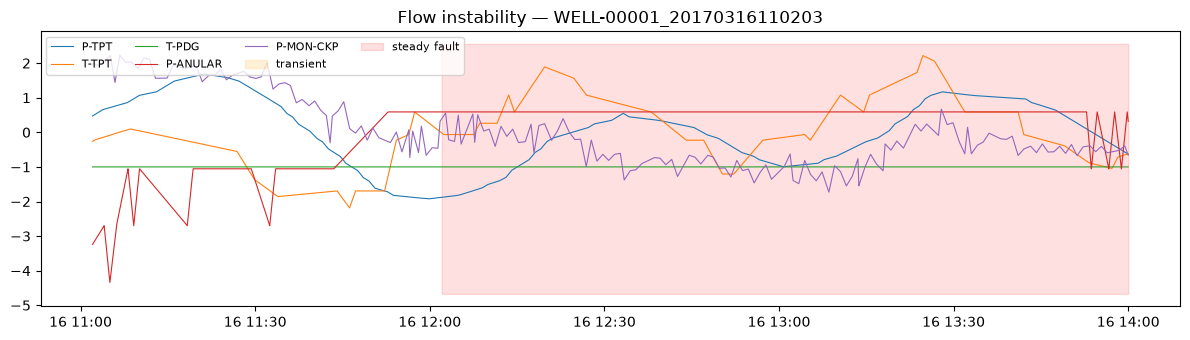

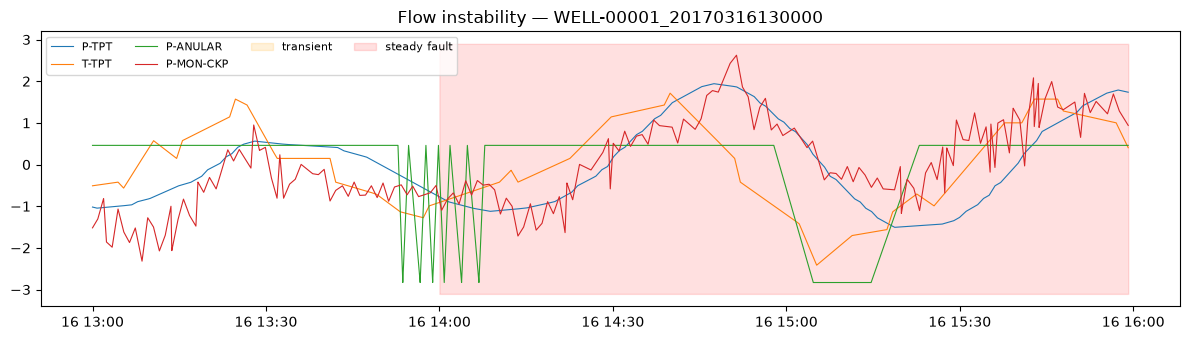

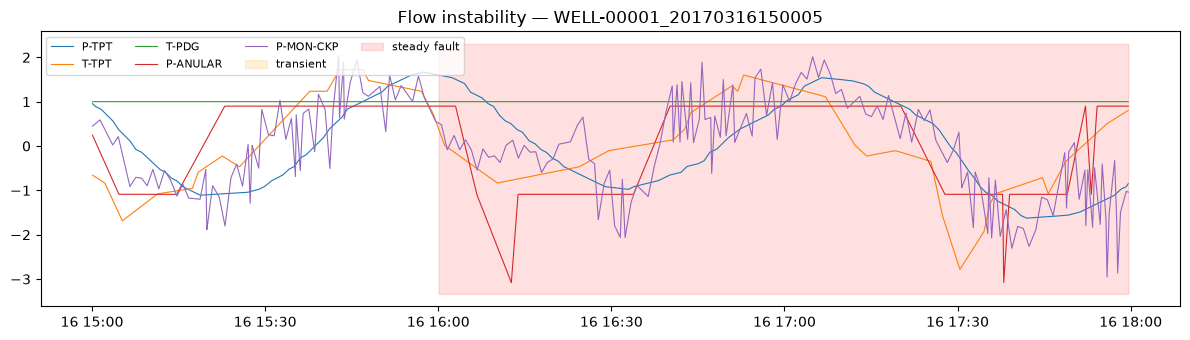

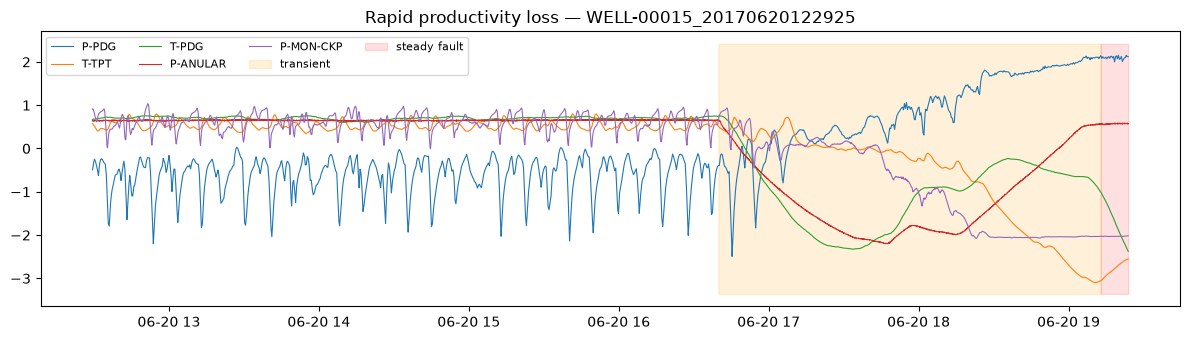

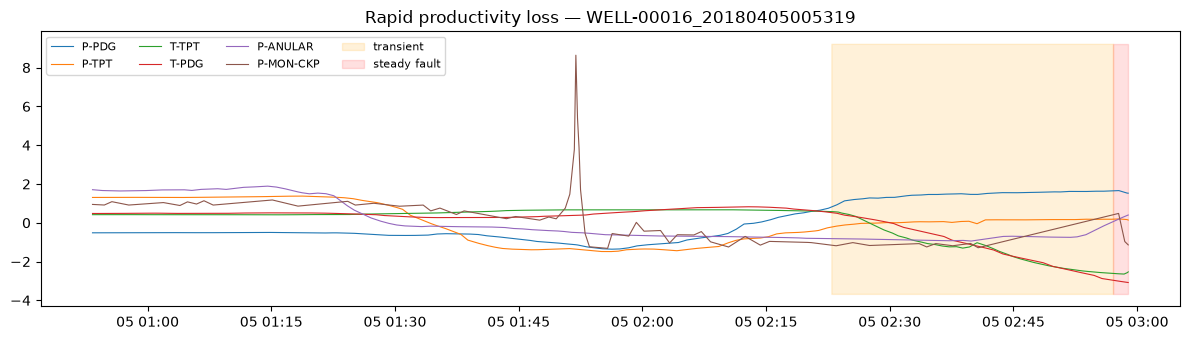

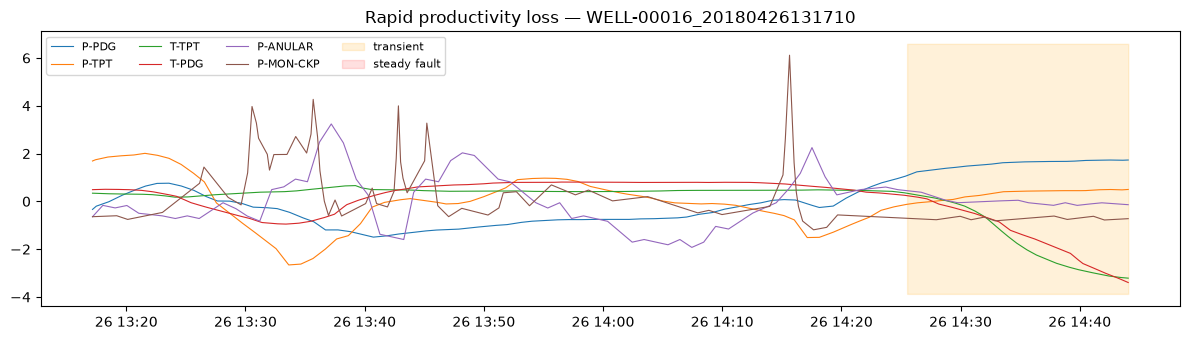

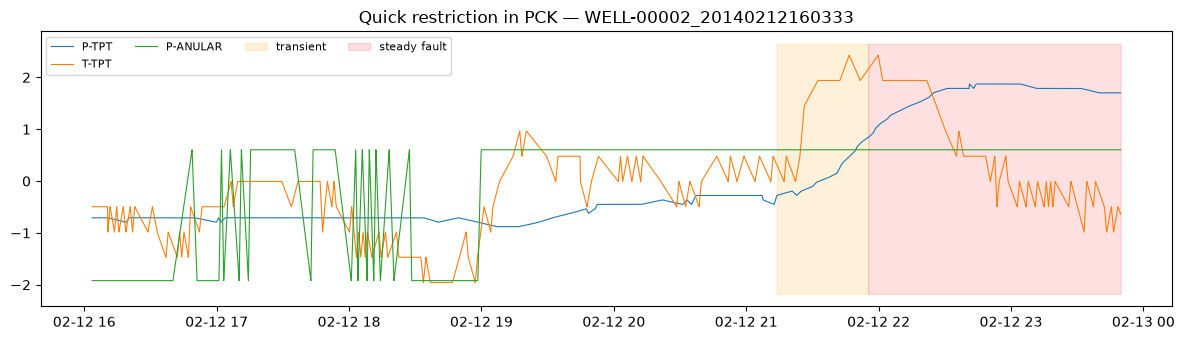

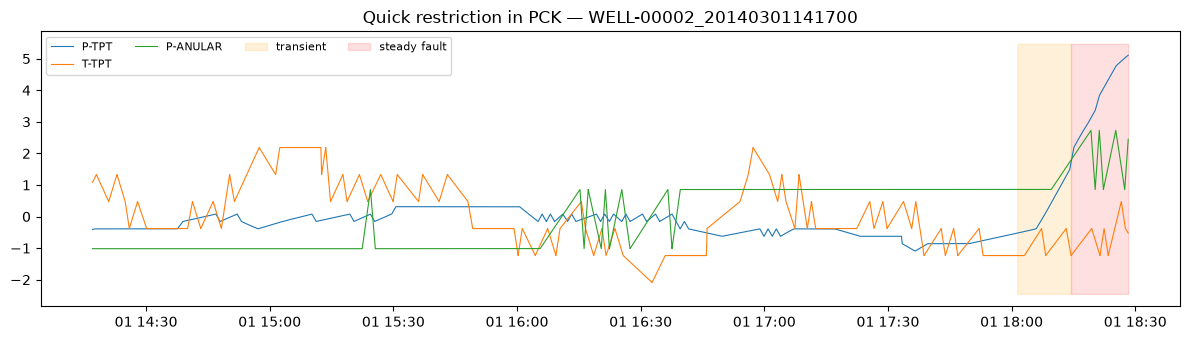

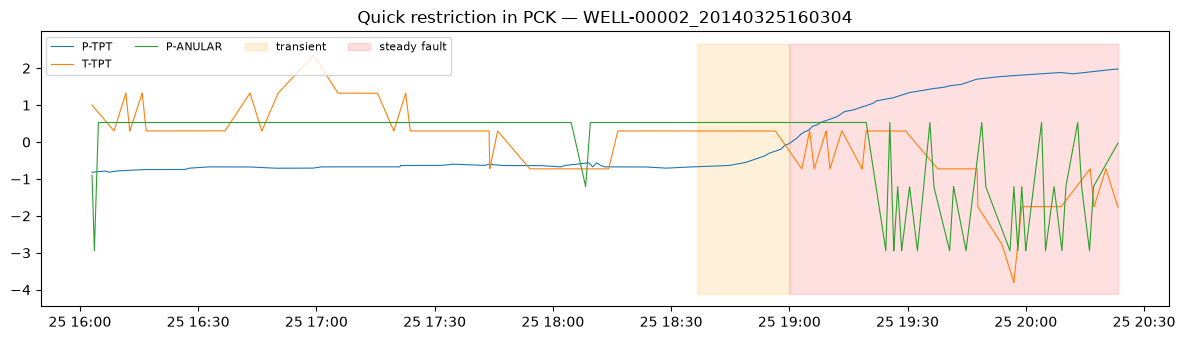

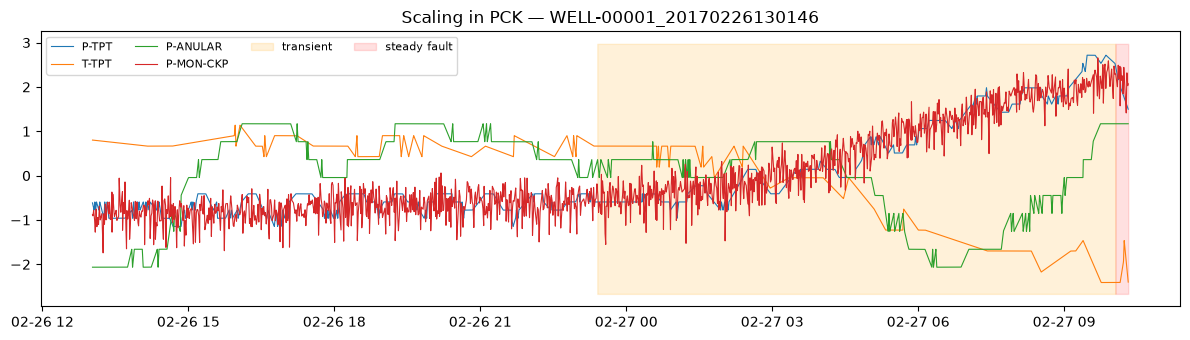

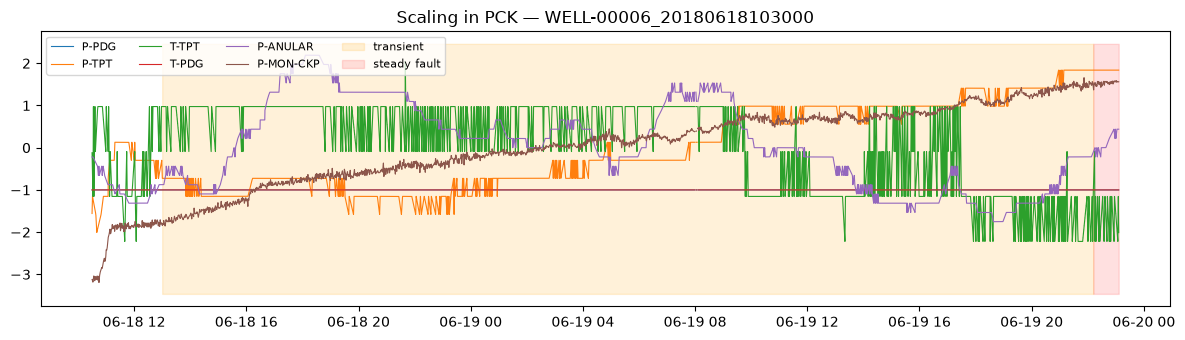

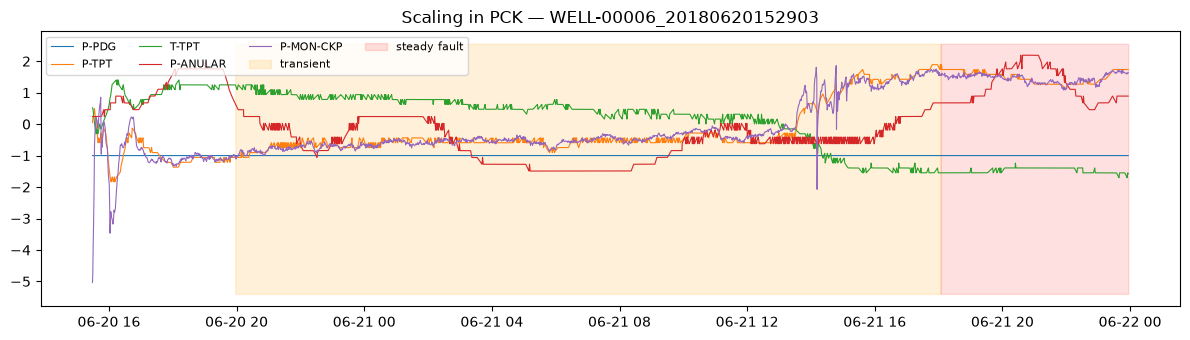

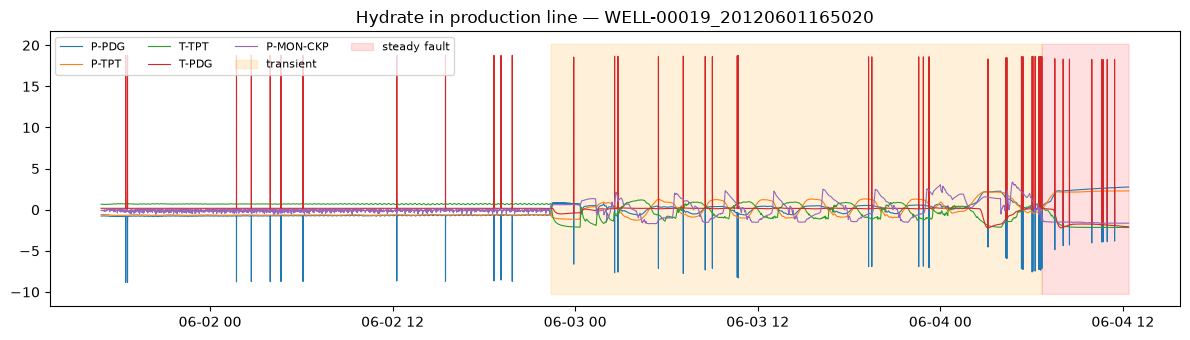

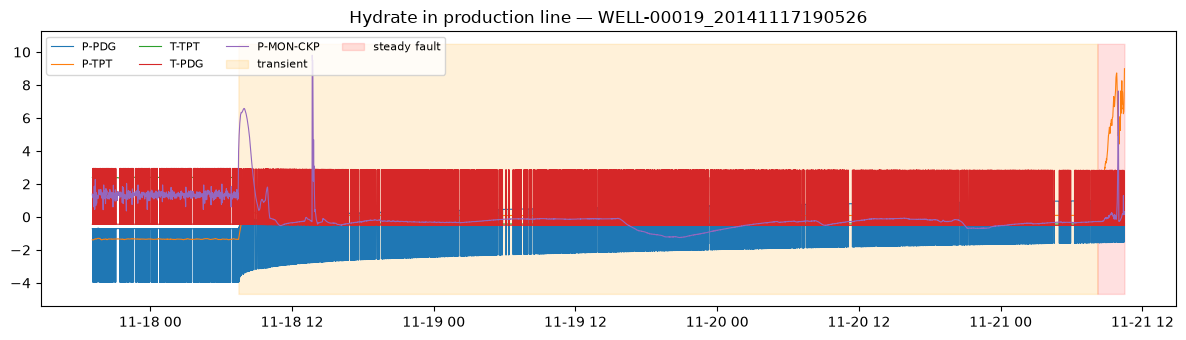

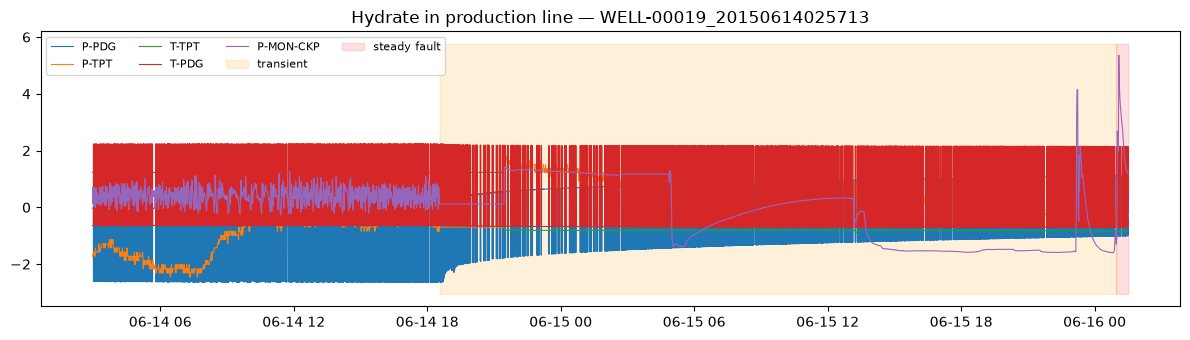

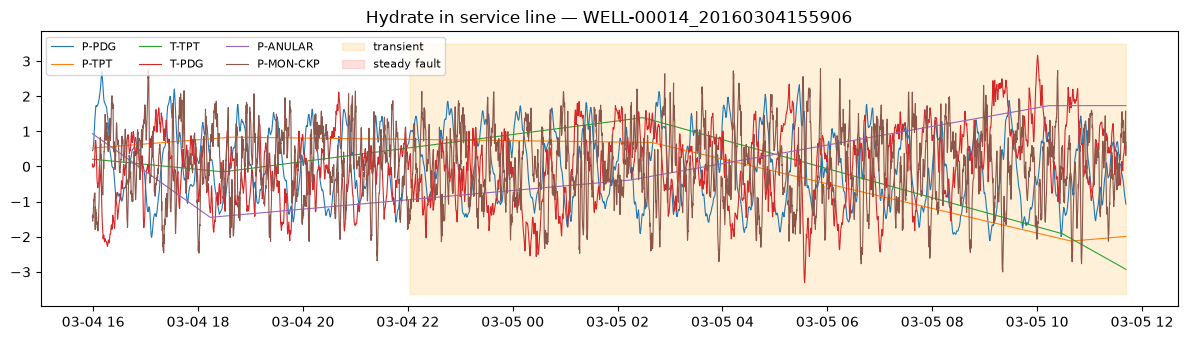

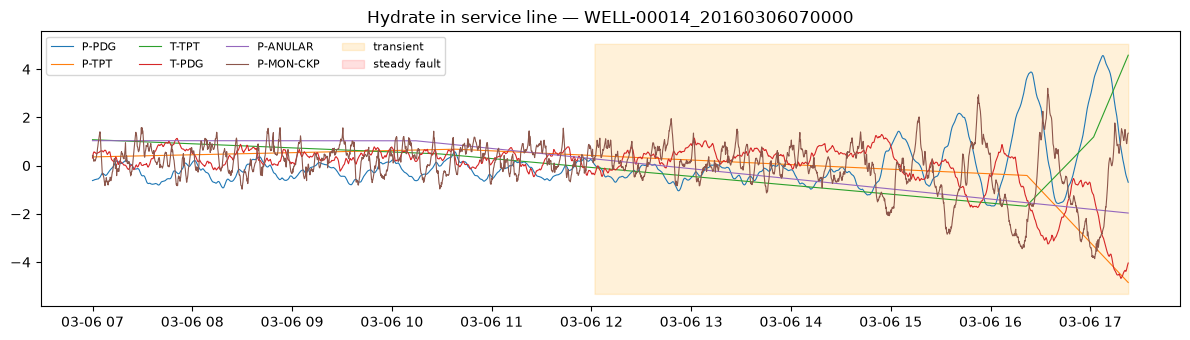

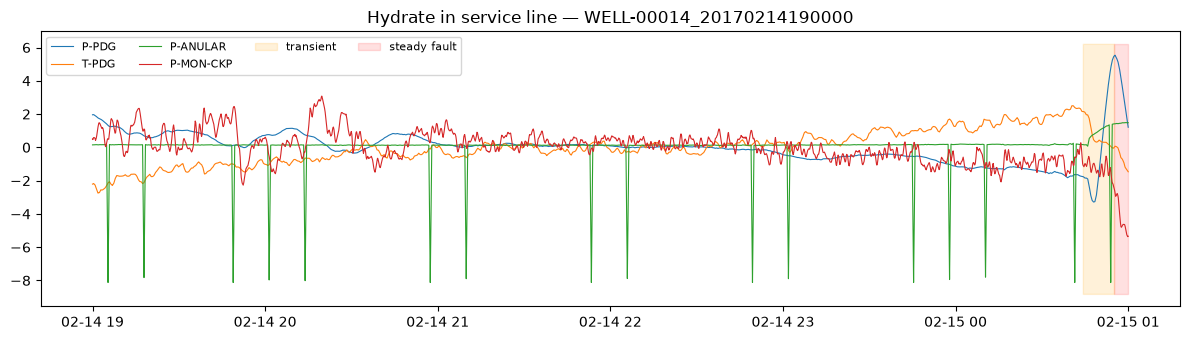

In [15]:
PLOT_SENSORS = ["P-PDG", #Pressure near reservoir
                "P-TPT", #Pressure in the subsea tree
                "T-TPT", #Temperature in the subsea tree
                "T-PDG", #Temperaturue near reservoir
                "P-ANULAR", #Pressure in the annulus area in the tubing
                "P-MON-CKP" #Pressure arriving at the surface
                ]

def plot_instance(row, sensors=PLOT_SENSORS):
    df = load_instance(row.path)
    cols = [c for c in sensors if c in df.columns and df[c].notna().any() and df[c].std() > 0]
    fig, ax = plt.subplots(figsize=(12, 3.5))
    for c in cols:
        ax.plot(df.index, (df[c] - df[c].mean()) / df[c].std(), lw=0.8, label=c)
    cls = df["class"].fillna(-1).astype(int)
    ymin, ymax = ax.get_ylim()
    ax.fill_between(df.index, ymin, ymax, where=cls >= 100, color="orange", alpha=0.15, label="transient")
    ax.fill_between(df.index, ymin, ymax, where=(cls > 0) & (cls < 100), color="red", alpha=0.12, label="steady fault")
    ax.set_title(f"{row.event} — {row.instance}")
    ax.legend(loc="upper left", fontsize=8, ncol=4)
    plt.tight_layout()
    plt.show()

for label in range(1, 10):
    candidates = summary[(summary["source"] == "real") & (summary["label"] == label)]
    if candidates.empty:
        print(f"No real instance for {EVENT_NAMES[label]}")
        continue
    with_transient = candidates[candidates["transient_frac"] > 0]
    pick = (with_transient if len(with_transient) else candidates).iloc[0]
    pick1 = (with_transient if len(with_transient) else candidates).iloc[1]
    pick2 = (with_transient if len(with_transient) else candidates).iloc[2]
    plot_instance(pick)
    plot_instance(pick1)
    plot_instance(pick2)

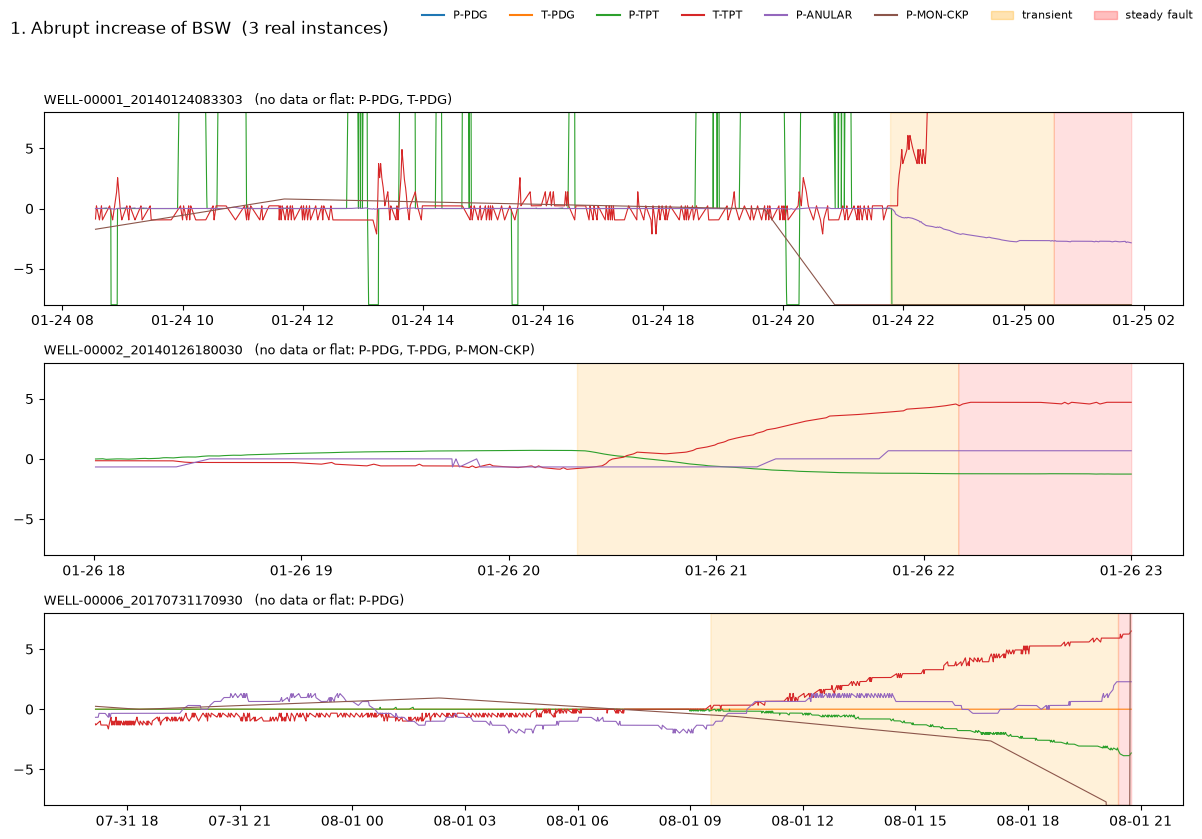

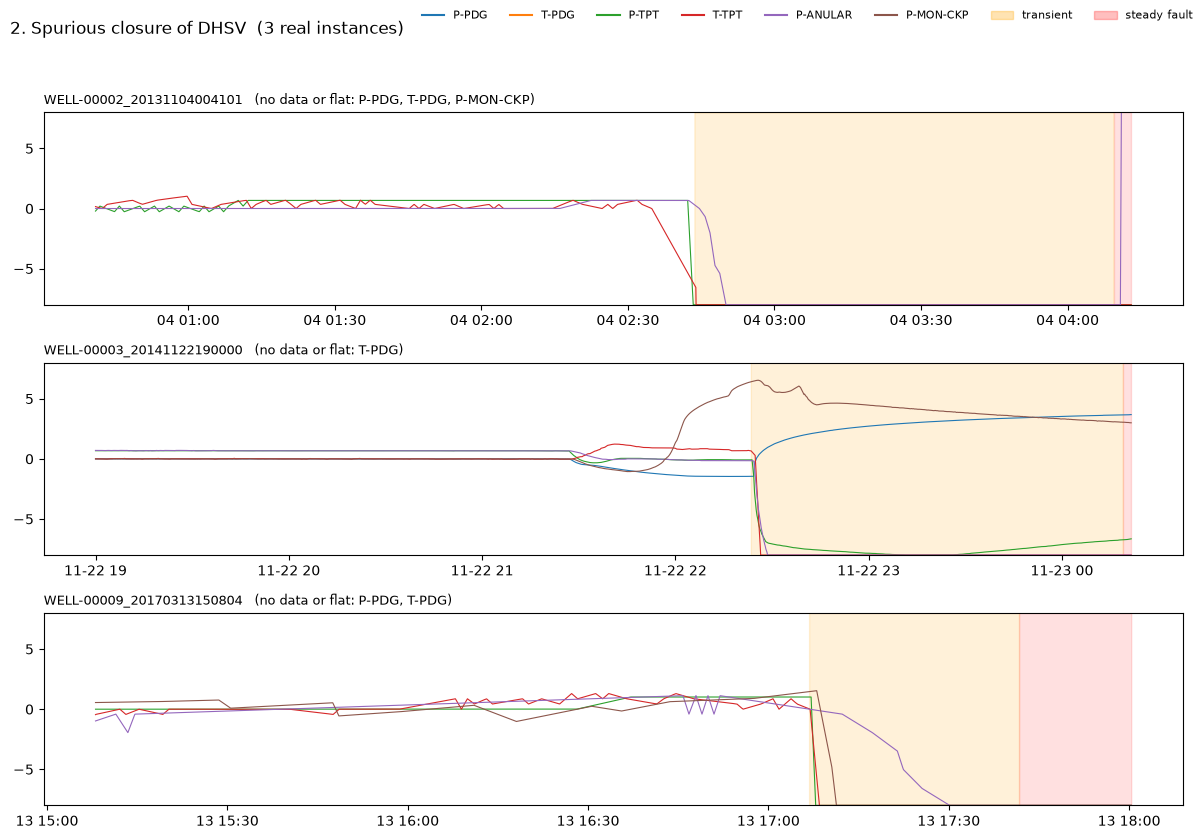

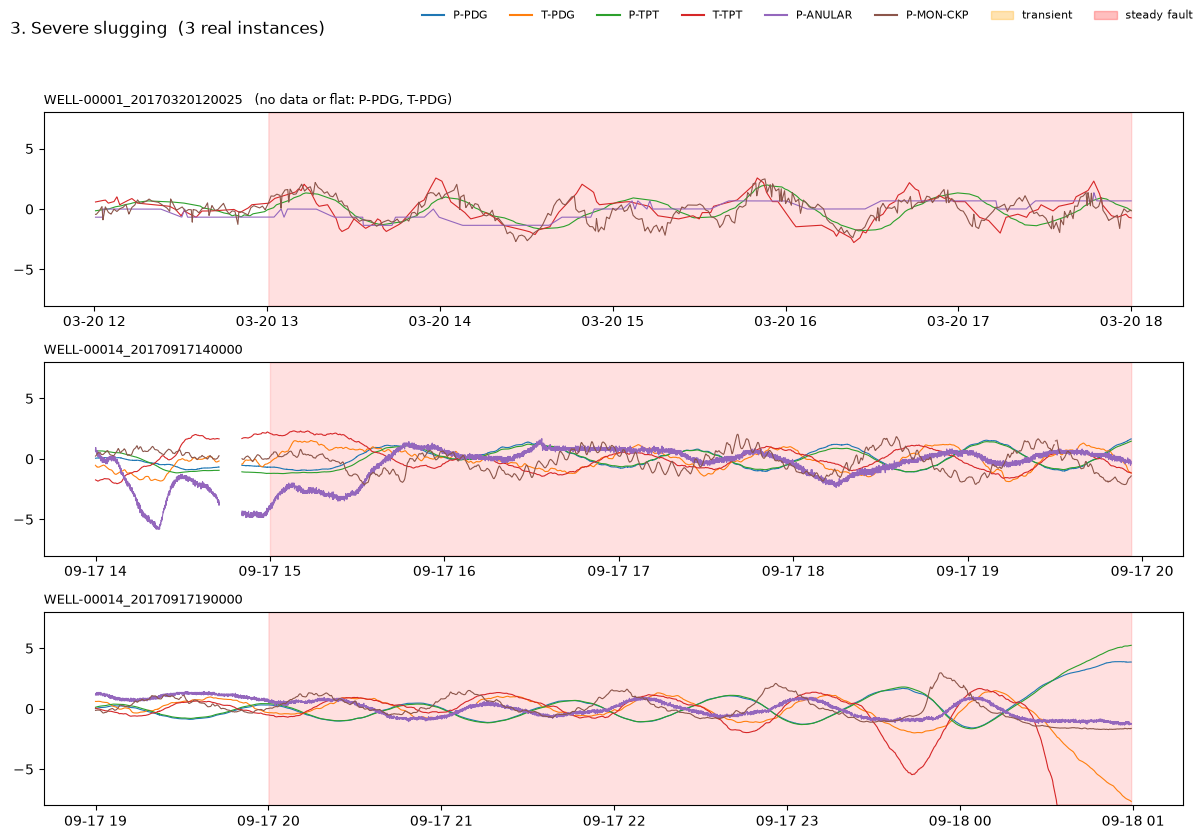

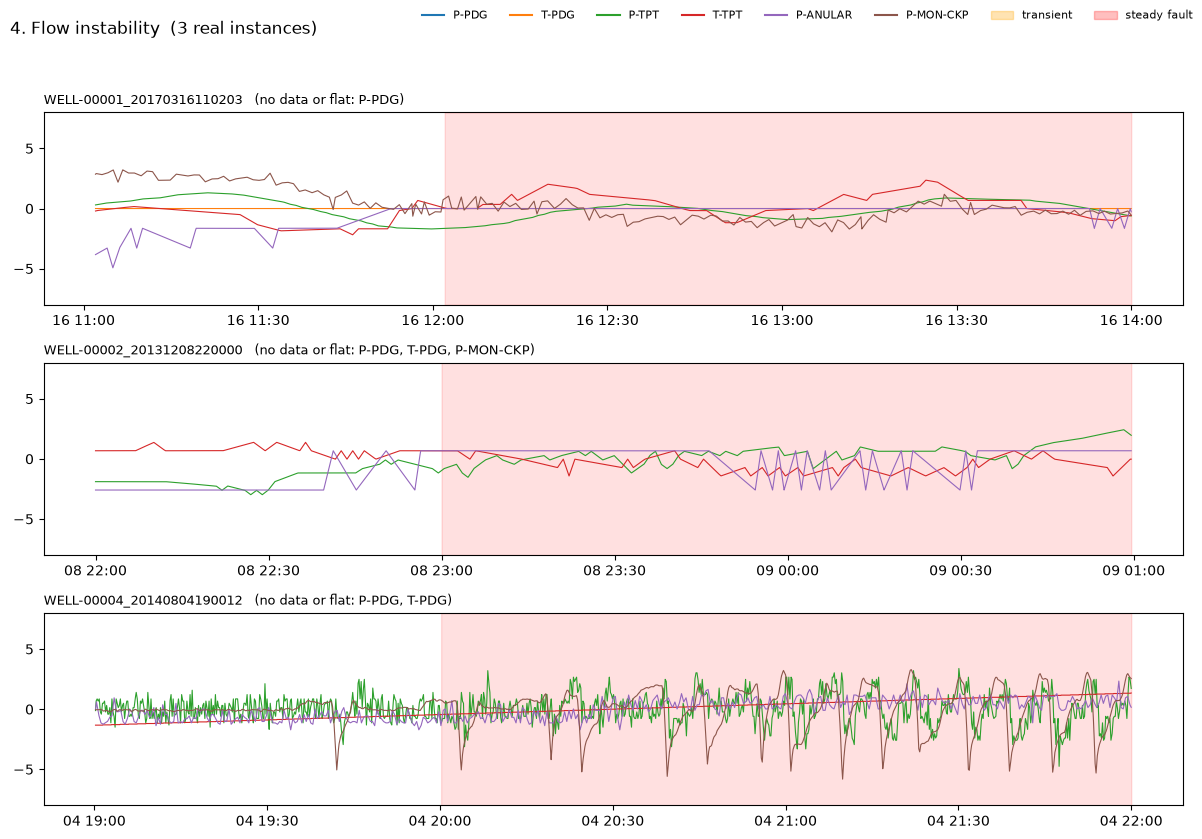

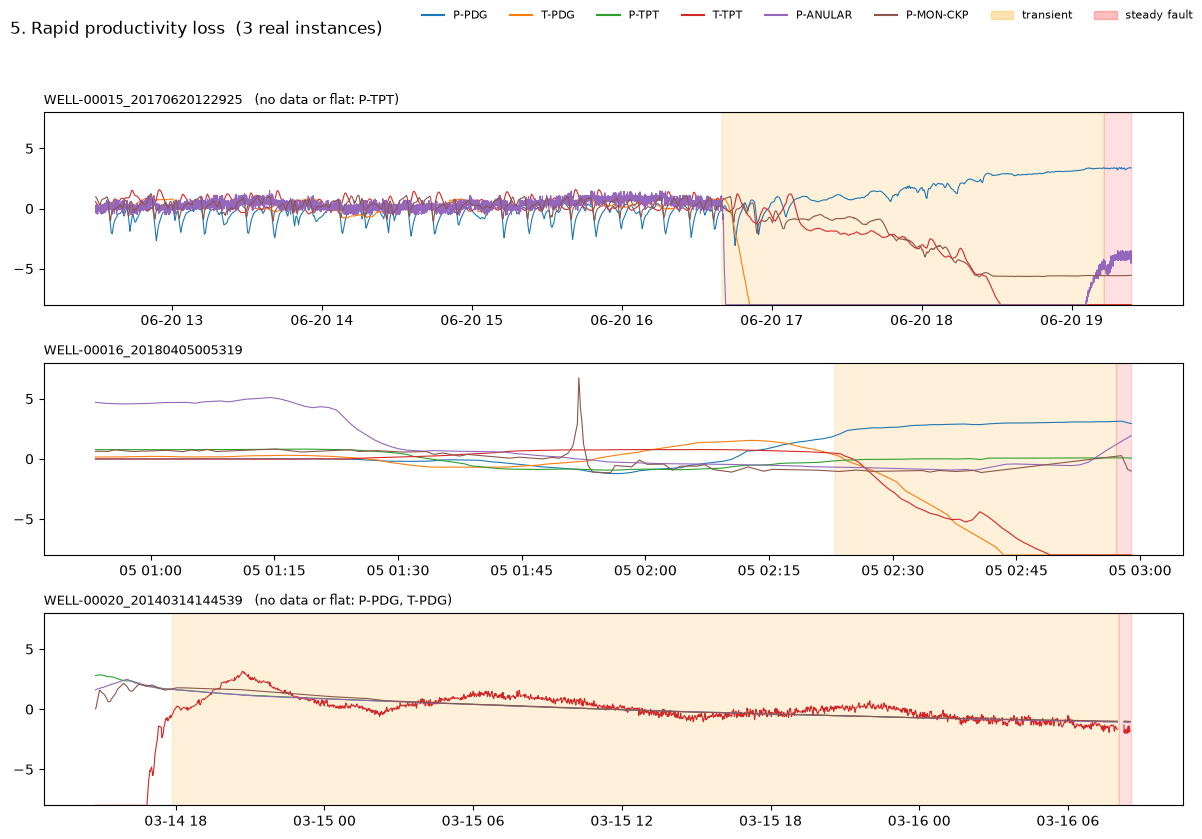

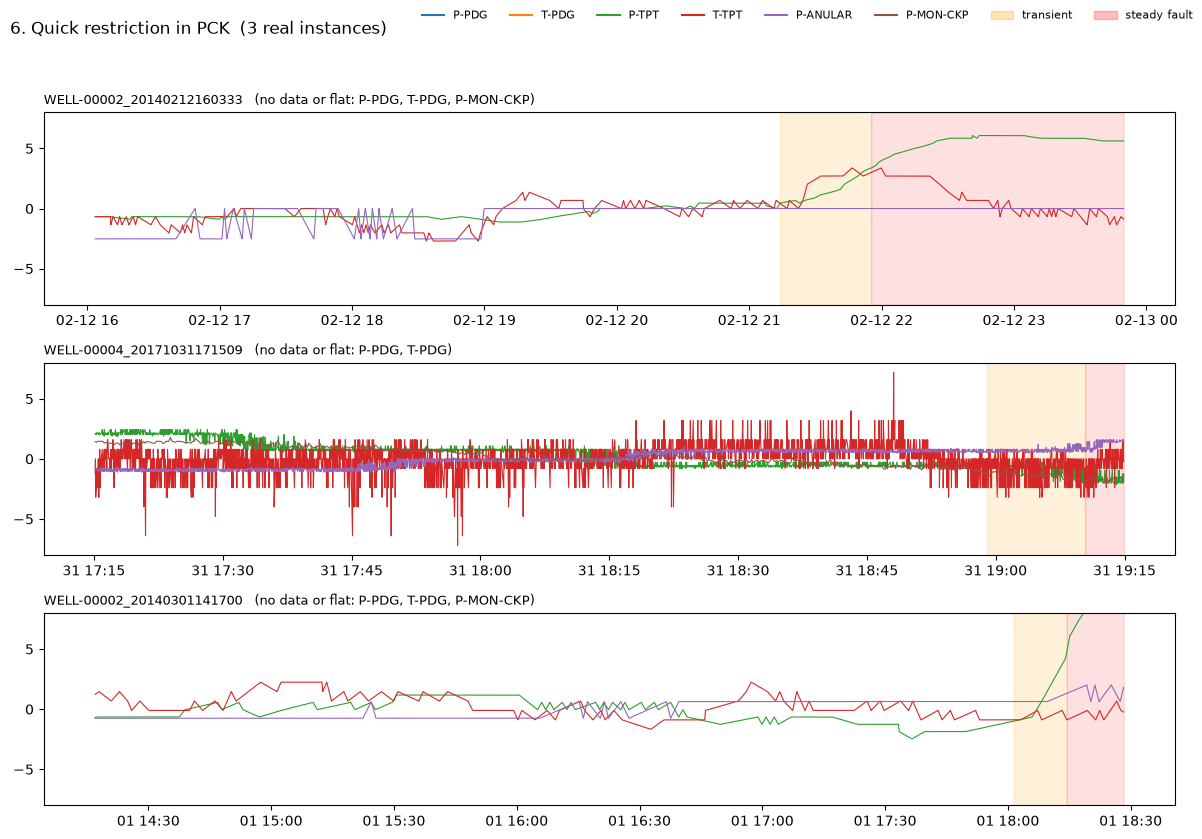

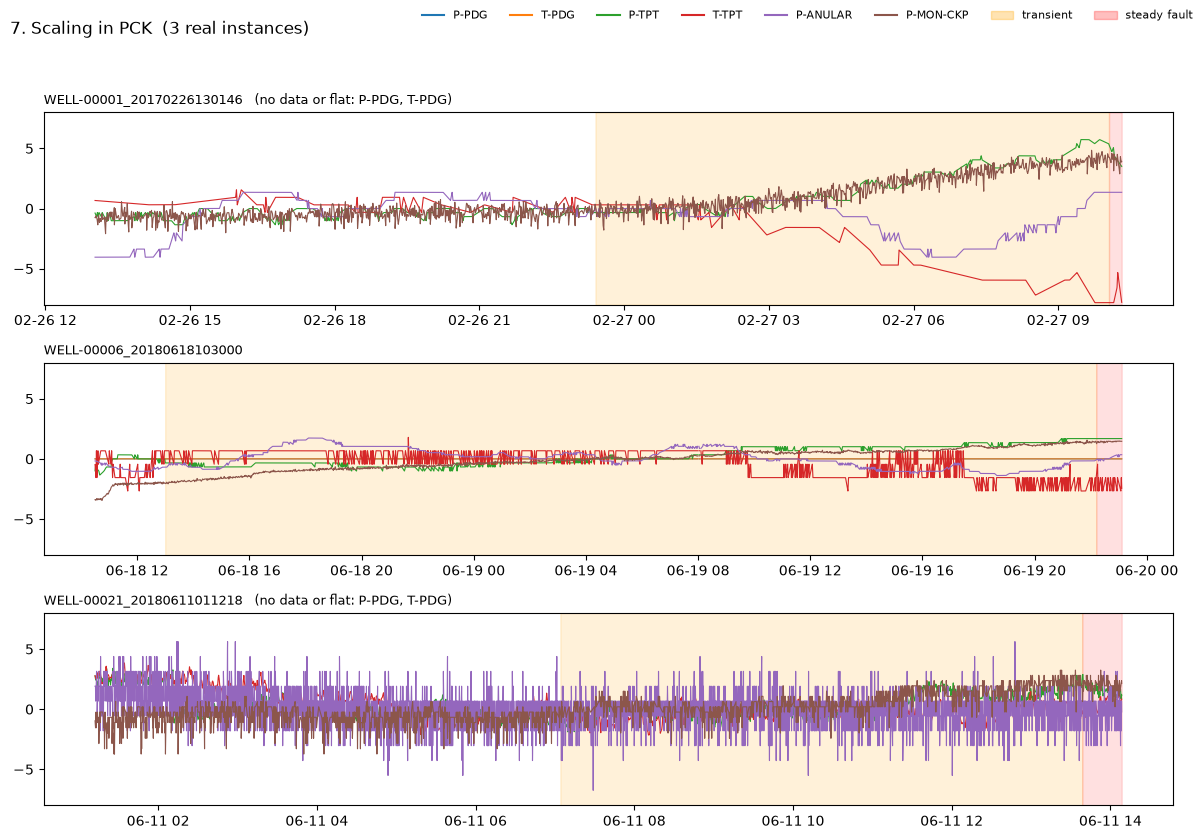

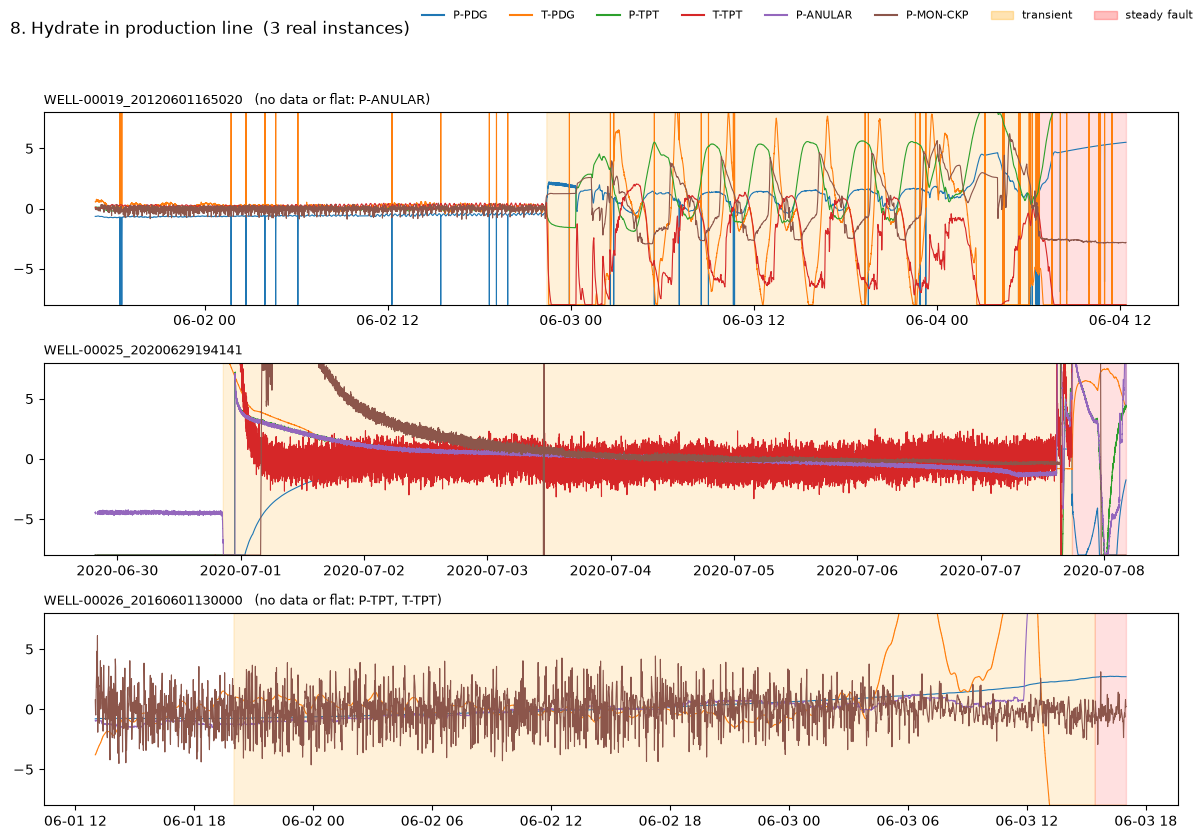

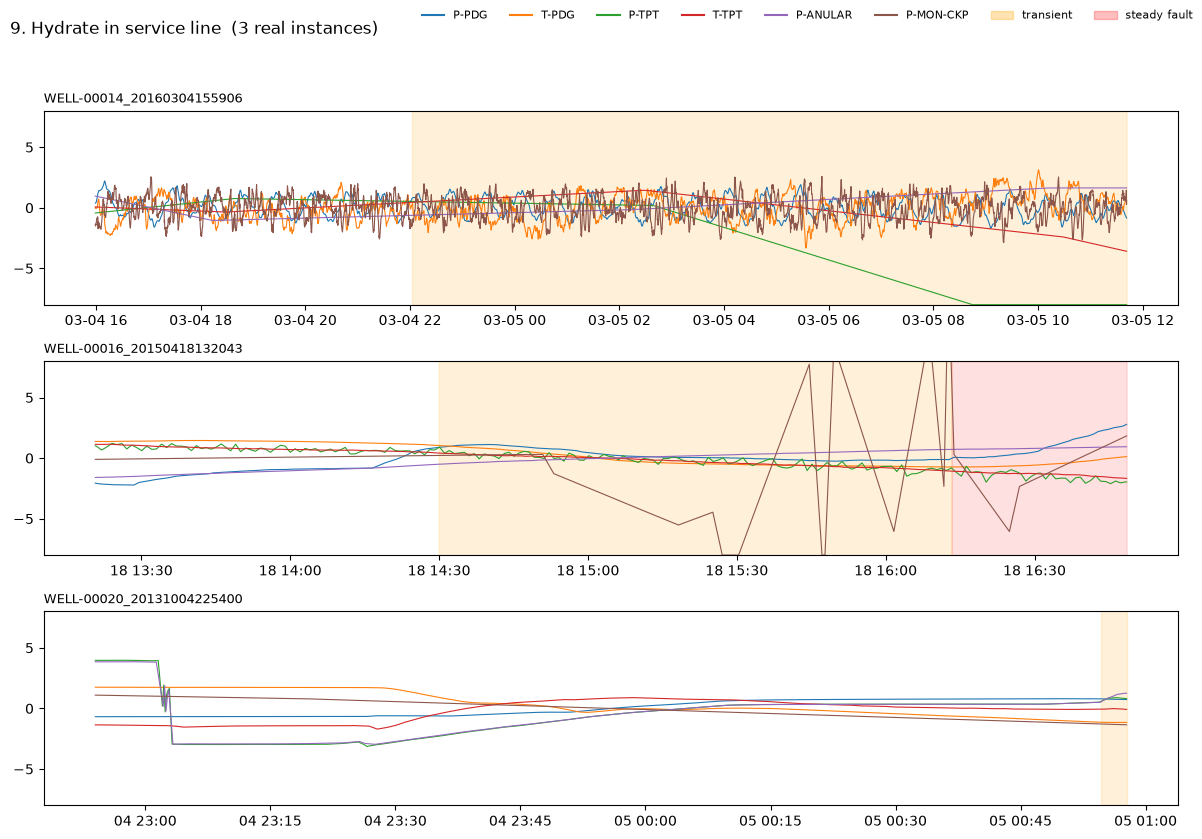

In [17]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

PLOT_SENSORS = [
    "P-PDG",      # pressure near the reservoir
    "T-PDG",      # temperature near the reservoir
    "P-TPT",      # pressure at the subsea tree
    "T-TPT",      # temperature at the subsea tree
    "P-ANULAR",   # pressure in the annulus (gap around the tubing)
    "P-MON-CKP",  # pressure arriving at the surface, before the choke
]
# One fixed colour per sensor, so a sensor looks the same in every plot
SENSOR_COLORS = dict(zip(PLOT_SENSORS, plt.cm.tab10.colors))
CLIP = 8  # scaled values beyond 8 stdv are treated as glitches and clipped
N_PER_FAULT = 3


def pick_instances(label, n=N_PER_FAULT):
    """Up to n real instances of one fault: ones with a transient first, then different wells first."""
    cands = summary[(summary["source"] == "real") & (summary["label"] == label)]
    cands = cands.assign(has_transient=cands["transient_frac"] > 0)
    cands = cands.sort_values("has_transient", ascending=False, kind="stable")
    one_per_well = cands.drop_duplicates("well")
    rest = cands.drop(one_per_well.index)
    return pd.concat([one_per_well, rest]).head(n)


def robust_scale(x):
    """Centre on the median and scale by the MAD, so a few huge glitches can't squash the plot.
    (A normal z-score uses mean and std, which the glitches themselves inflate.)"""
    mad = (x - x.median()).abs().median() * 1.4826  # 1.4826 makes MAD comparable to std
    scale = mad if mad > 0 else x.std()
    return ((x - x.median()) / scale).clip(-CLIP, CLIP)


def draw_instance(ax, row, sensors=PLOT_SENSORS):
    """Plot one instance on one axis: robust-scaled sensors, fault phases shaded."""
    df = load_instance(row.path)
    present = [c for c in sensors if c in df.columns and df[c].notna().any() and df[c].std() > 0]
    absent = [c for c in sensors if c not in present]

    for c in present:
        ax.plot(df.index, robust_scale(df[c]), lw=0.8, color=SENSOR_COLORS[c])

    cls = df["class"].fillna(-1).astype(int)
    ax.fill_between(df.index, -CLIP, CLIP, where=cls >= 100, color="orange", alpha=0.15)
    ax.fill_between(df.index, -CLIP, CLIP, where=(cls > 0) & (cls < 100), color="red", alpha=0.12)
    ax.set_ylim(-CLIP, CLIP)

    title = f"{row.instance}"
    if absent:
        title += f"   (no data or flat: {', '.join(absent)})"
    ax.set_title(title, fontsize=9, loc="left")


legend_items = [Line2D([], [], color=SENSOR_COLORS[c], label=c) for c in PLOT_SENSORS] + [
    Patch(color="orange", alpha=0.3, label="transient"),
    Patch(color="red", alpha=0.25, label="steady fault"),
]

for label in range(1, 10):
    picks = pick_instances(label)
    if picks.empty:
        print(f"No real instance for {EVENT_NAMES[label]}")
        continue

    fig, axes = plt.subplots(len(picks), 1, figsize=(12, 2.8 * len(picks)), squeeze=False)
    for ax, (_, row) in zip(axes[:, 0], picks.iterrows()):
        draw_instance(ax, row)

    fig.suptitle(f"{label}. {EVENT_NAMES[label]}  ({len(picks)} real instances)", fontsize=12, x=0.01, ha="left")
    fig.legend(handles=legend_items, loc="upper right", ncol=8, fontsize=8, frameon=False)
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

6 candidate sensors (present and moving in at least half of real instances):


['T-TPT', 'P-TPT', 'P-ANULAR', 'P-MON-CKP', 'P-JUS-CKGL', 'T-JUS-CKP']

In [19]:
real.groupby("event")["well"].nunique().sort_values()

event
Quick restriction in PCK       2
Severe slugging                2
Rapid productivity loss        3
Abrupt increase of BSW         3
Scaling in PCK                 6
Flow instability               7
Spurious closure of DHSV       7
Hydrate in production line     9
Normal operation               9
Hydrate in service line       15
Name: well, dtype: int64